# Classify traffic signs

This Jupyter Notebook is about the recognition of traffic signs. The dataset used for this is the German Traffic Sign Recognition Benchmark, or GTSRB for short. All information about the dataset can be viewed online (http://benchmark.ini.rub.de/?section=gtsrb&subsection=news).

### Introduction
Some tasks that are easy for humans are highly complex from a mathematical point of view. 
Spoken language or images of everyday situations can only be learnt by ML methods with great effort.
A common approach is known as feature engineering:
Domain experts (i.e. experts in image processing or linguists) define how relevant information can be extracted from the raw data.
As an ML expert, you can follow the suggestions and extract the most important information for the selected context.
The aim of the exercise is to sharpen the understanding of feature engineering with its strengths and weaknesses.
Using traffic signs as an example, an entire pipeline is presented that can be improved at various points by exchanging methods and modifying parameters.



### General instructions about the exercise

Open the Jupyter Notebook "Classify Traffic Signs.jpynb".
In the lecture you have already been asked to download the traffic sign data.
Enter the path to the traffic sign data so that the data set loads.
If you have any problems, contact the exercise group leader.
Run the notebook completely once and make sure that no errors have occurred.
This will be the so-called "Baseline" for this task:
The comparison variable that you use to indicate whether you have already been able to improve the result.

### Identification of potentials

With larger projects, there is very quickly a wealth of different variants that can be tried out.
What changes could be helpful in this context to better classify traffic signs?

Task: Name three places in the notebook where a change could lead to better results.
You can select individual parameters, but also entire processing steps or algorithms.

### Understanding the code

Look at the entire notebook and research what the lines of code mean if you are unsure. 
For this week's tasks, it is important to trace the flow of data from the database via preprocessing.
With respect to the learning algorithm, specifics regarding image preprocessing by external libraries are not important.

Task:
Replace the placeholders for headings with descriptive titles.
Outline the individual steps in the notebook in your own words.

In [15]:
import numpy as np
import os.path
import imageio
import skimage.transform
import skimage.feature
import skimage.color
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay

import gtsrb_db_loader  # this is a self-written module in the same folder

With this code snippet, the ZIP file is downloaded automatically

In [16]:
import functools
import shutil
import requests
from tqdm.auto import tqdm

file_name = "GTSRB_Final_Training_Images.zip"
if file_name not in os.listdir("."):
    url = "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip"
    r = requests.get(url, stream=True, allow_redirects=True)
    if r.status_code != 200:
        r.raise_for_status()
        raise RuntimeError(f"Request to {url} returned status code {r.status_code}")
    file_size = int(r.headers.get('Content-Length', 0))
    desc = "(Unknown total file size)" if file_size == 0 else "Downloading"
    r.raw.read = functools.partial(r.raw.read, decode_content=True)
    with tqdm.wrapattr(r.raw, "read", total=file_size, desc=desc) as r_raw:
        with open(file_name, "wb") as f:
            shutil.copyfileobj(r_raw, f)
else:
    print(f"Datei '{file_name}' ist bereits heruntergeladen")

print("Inhalt des Ordners:")
for file_entry in os.listdir("."):
    print("- ", file_entry)

Datei 'GTSRB_Final_Training_Images.zip' ist bereits heruntergeladen
Inhalt des Ordners:
-  book-4.ipynb
-  book-2.ipynb
-  gtsrb_db_loader.py
-  book-5.ipynb
-  book-1.ipynb
-  book-3.ipynb
-  __pycache__
-  GTSRB_Final_Training_Images
-  GTSRB_Final_Training_Images.zip
-  .ipynb_checkpoints
-  GTSRB


The ZIP file is now unpacked into the subfolder `GTSRB_Final_Training_Images`:

In [17]:
import zipfile

folder_name = "GTSRB_Final_Training_Images"

if folder_name not in os.listdir("."):
    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall("GTSRB_Final_Training_Images")
else:
    print("The target folder for unpacking already exists")

The target folder for unpacking already exists


Instead of the previous two code cells, you can also simply the ZIP archive from
[here](https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip)
and unzip it in the same folder as the Jupyter Notebook.

## Load Traffic Sign Dataset

Loads the GTSRB dataset from the specified directory into a pandas DataFrame

Put the directory `GTSRB` in the same directory as the notebook.
If copying takes too long, adjust `path_to_directory` so that the path points to the unpacked folder with the traffic signs.

In [18]:
# start in the same folder (relative path)
# adjust the path if necessary!
path_to_directory = "./GTSRB_Final_Training_Images"

# alternatively: specify the absolute path, remember that backslashes are interpreted differently in Python
#path_to_directory = "C:/asdfasdf/"

df = gtsrb_db_loader.load_traffic_sign_database(path_to_directory)

df.head()

,Filename,Width,Height,Roi_X1,Roi_Y1,Roi_X2,Roi_Y2,ClassId,path_to_image
0,00000_00000.ppm,38,35,5,5,33,30,31,./GTSRB_Final_Training_Images/GTSRB/Final_Trai...
1,00000_00001.ppm,40,36,6,5,34,31,31,./GTSRB_Final_Training_Images/GTSRB/Final_Trai...
2,00000_00002.ppm,40,37,5,5,34,32,31,./GTSRB_Final_Training_Images/GTSRB/Final_Trai...
3,00000_00003.ppm,41,39,6,6,36,34,31,./GTSRB_Final_Training_Images/GTSRB/Final_Trai...
4,00000_00004.ppm,43,37,6,5,38,32,31,./GTSRB_Final_Training_Images/GTSRB/Final_Trai...


## Image Preprocessing

Reads each image, converts to grayscale, crops using ROI (Region of Interest) coordinates, and resizes to 40x40 pixels

In [19]:
images = []
for row in gtsrb_db_loader.log_progress(df.itertuples(), size=len(df)):
    color_image = imageio.v2.imread(row.path_to_image).astype(int, copy=False)
    gray_image = skimage.color.rgb2gray(color_image)
    cropped_image = gray_image[row.Roi_Y1:row.Roi_Y2, row.Roi_X1:row.Roi_X2]
    resized_image = skimage.transform.resize(cropped_image, [40, 40], mode="constant")
    images.append(resized_image)
df = df.assign(image=images)

A traffic sign now looks like this:

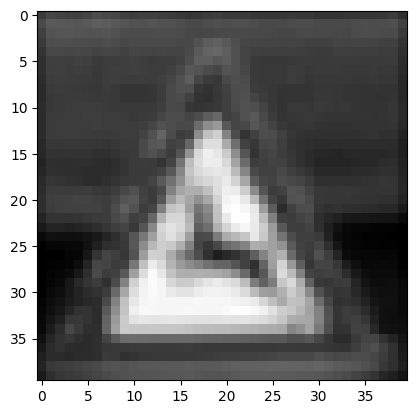

In [20]:
sample_image = df.iloc[0].image
plt.imshow(sample_image, cmap='gray')
plt.show()

## Feature Extraction using HOG (Histogram of Oriented Gradients)

Extracts HOG features from preprocessed images to create feature vectors for classification

Using Histograms of Gradients (HOGs) objects can be easily classified automatically.
These are used, for example, to classify objects in a specific way in the article
["Histograms of Oriented Gradients for Human Detection" by N. Dalal und B. Triggs](https://hal.inria.fr/docs/00/54/85/12/PDF/hog_cvpr2005.pdf)
is well described.
The HOGs of the example image shown above are shown below.

A simple way to convert images to HOGs is provided by
[scikit-image](http://scikit-image.org/docs/dev/api/skimage.feature.html#skimage.feature.hog)
and used below.

First, we show what the HOG representation looks like for the traffic sign above.

#### What is Feature Engineering used for?

Now that we have discussed in the lecture that feature engineering is worthwhile for images, it is time to compare it with the interpretation of the image.

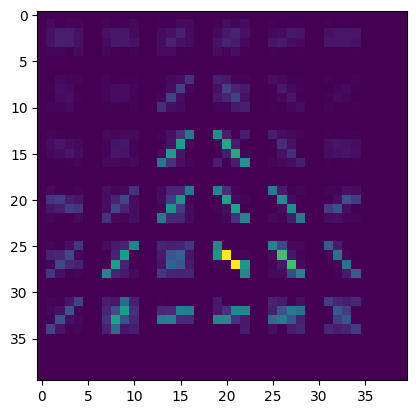

In [21]:
hog_img = skimage.feature.hog(
    sample_image,
    transform_sqrt=True,
    orientations=8,
    pixels_per_cell=(6, 6),
    cells_per_block=(3, 3),
    feature_vector=True,
    block_norm="L2-Hys",
    visualize=True
)[1]
plt.imshow(hog_img)
plt.show()

In [22]:
hog_features = []
for row in gtsrb_db_loader.log_progress(df.itertuples(), size=len(df)):
    hog_feature = skimage.feature.hog(
        row.image,
        transform_sqrt=True,
        orientations=8,   # there are 8 different edge groups
        pixels_per_cell=(6, 6),
        cells_per_block=(3, 3),
        feature_vector=True,
        block_norm="L2-Hys",
        visualize=False
    )
    hog_features.append(hog_feature)
df = df.assign(hog_feature=hog_features)

Now the Data is prepared to such an extent that the connection between the image and the traffic sign can be established using a suitable ML method.

#### Classification using the vector

You can use the following code to generate a 1d array from the 2d images.
You are familiar with this approach from digit recognition.
All lines of the image are concatenated for conversion.
You can visualise this as a 1 pixel high, very wide image.

In [23]:
images_1d = []
for row in df.itertuples():
    images_1d.append(row.image.flatten())
df = df.assign(image_1d=images_1d)

#Add the code in a cell before the split in training and test data.

Set "images_1d" as a feature by adapting the following line accordingly.
	
features = df["hog_feature"].values

## Split Data into Training and Test Sets

Divides the dataset into training (67%) and test (33%) sets for model evaluation

In [24]:
features = df["hog_feature"].values
targets = df["ClassId"].values

X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.33)

One more small thing:
The HOGs are available as arrays of arrays, but the learning algorithm requires a single long array.
For this, the arrays must be concatenated.
This can be done easily using [`np.stack`](https://docs.scipy.org/doc/numpy-1.14.0/reference/generated/numpy.stack.html).

In [25]:
X_train = np.stack(X_train)
X_test = np.stack(X_test)

## Train Random Forest Classifier and Evaluate Results

Trains a Random Forest model and evaluates accuracy with confusion matrix visualization

A Random Forest (RF) is used as a classification algorithm.
The Random Forest is an ensemble of several decision trees.
In the following, an [implementation of scikit-learn](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) is used.

Various aspects can now be considered to evaluate the results.
The accuracy is a simple measure to quantify the proportion of correctly determined classes.
The Confusion Matrix makes it possible to see which classes are confused with each other.

In [26]:
random_forest = RandomForestClassifier(
    n_estimators=10,
    max_depth=7,
    n_jobs=-1,
    max_features="sqrt",
    class_weight=None
)
random_forest.fit(X_train, y_train)
score = random_forest.score(X_test, y_test)
print("Accuracy: {score} %".format(score=score*100))

Accuracy: 73.17412473916067 %


A nice way to visualize a confusion matrix is ​​to plot it as an image.
The following code is taken from the 
[scikit-learn documentation](http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html)
and adapted.
The traffic signs (as a list in the variable `classes`) are represented by the numbers 0 to 42. This corresponds to the class names from the lecture.

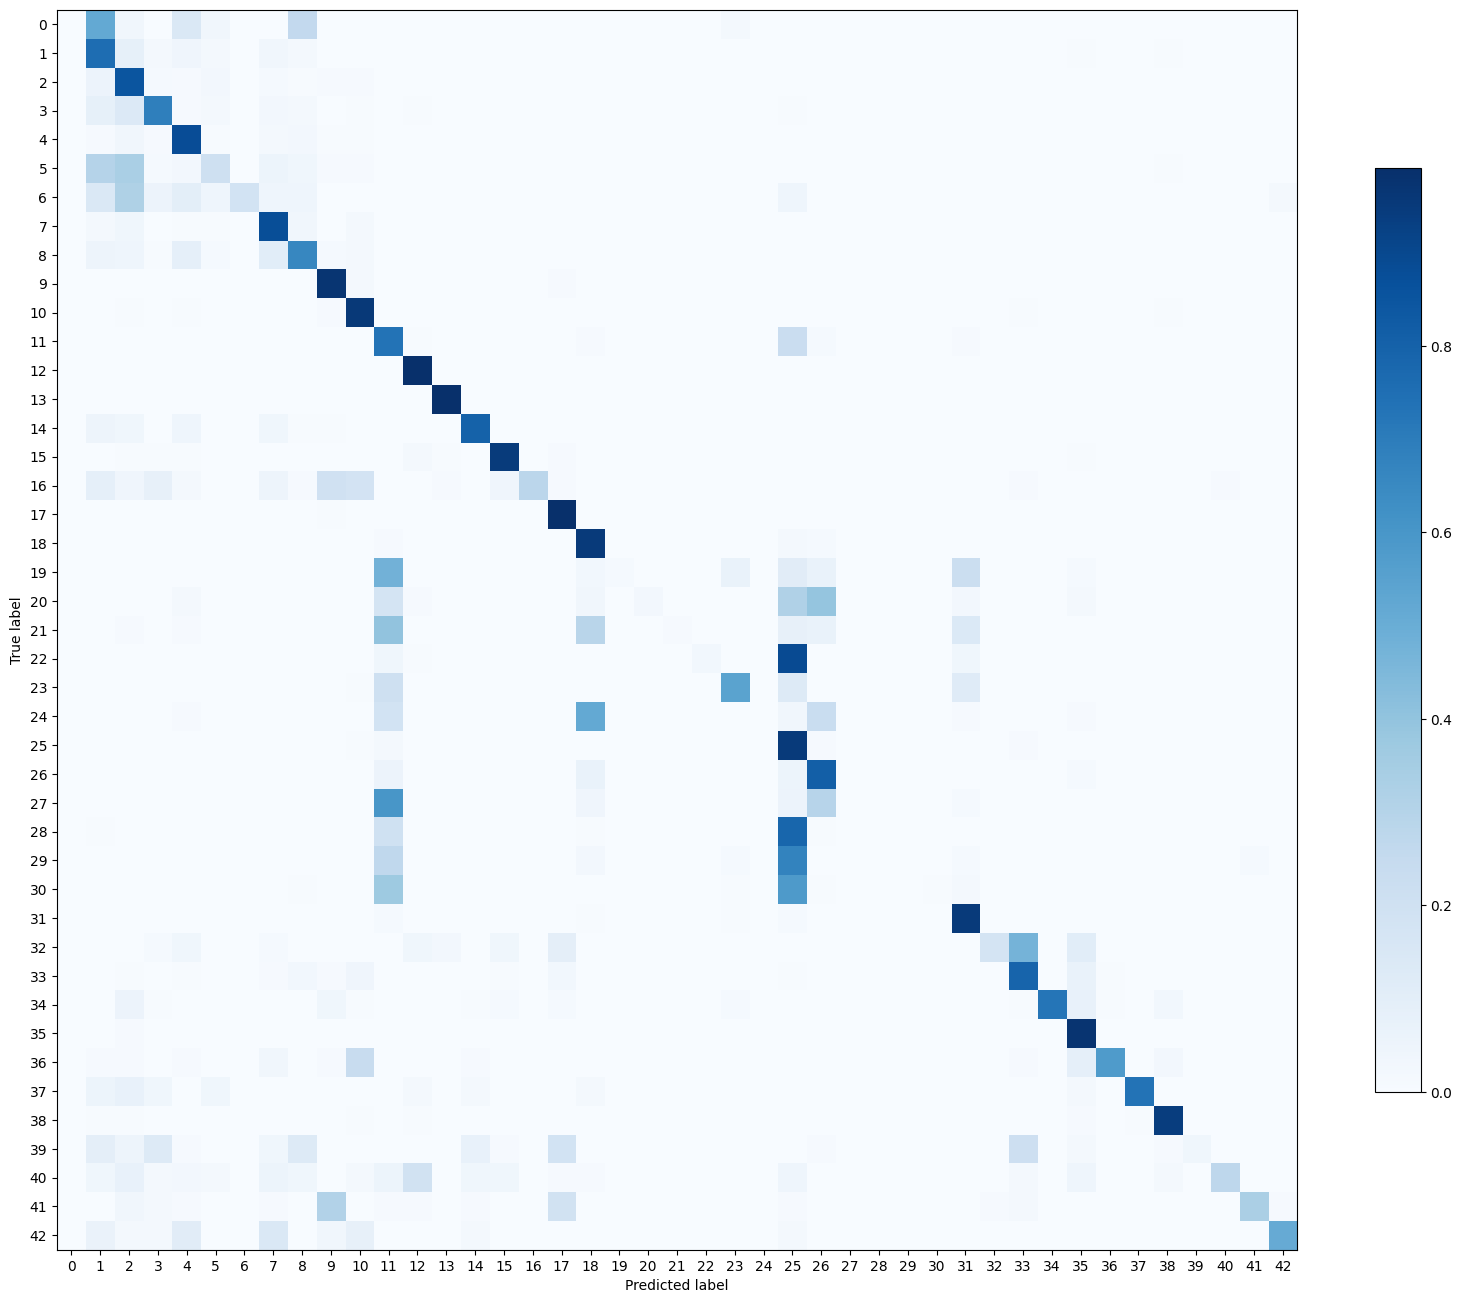

In [27]:
fig, ax = plt.subplots(figsize=(20, 20))
matrix = ConfusionMatrixDisplay.from_estimator(
    random_forest, X_test, y_test, include_values=False, cmap=plt.cm.Blues, ax=ax, normalize='true'
)
ax.images[-1].colorbar.remove()
plt.colorbar(matrix.im_, shrink=0.6)
plt.show()

Calculate five runs with the images and make a note of the results.
Inspect the confusion matrix.
What do you notice?

#### Probability of a correct classification

A model that randomly determines the class will also be correct according to the motto "A blind hen sometimes finds a grain".
This is why it is sometimes worth comparing with a random classification.

Task: Choose any two classes of traffic signs.
Determine the probability that if the algorithm predicts this traffic sign, the algorithm will be correct.
Also write down the mathematical formula you used to arrive at the result.

P(correct | predicted class i) = True Positives for class i / Total predictions for class i

### The path to a better result 

#### Comparison of the baseline with a new variant
Select the measure from the previous task that you expect will most likely improve the result.
Now copy the Jupyter notebook and give the copy a suitable name.
Then make the changes you have considered in the new notebook.
Keep the previous Jupyter notebooks in a safe place so that you can present your solutions at any time.

Task: Record exactly what you have changed.
Perform the classification of the original notebook and note the accuracy of five runs.
Perform the classification of the modified notebook and note the accuracy for five different runs.
Compare the measurement series with the baseline.

#### Second attempt for better results
If you were successful in the previous task, baseline-versus-new, congratulations!
If not, this is quite normal in a data science project, because there is never a guarantee of success.
Either way, you now have the opportunity to try out further variations.
Now copy the notebook and give the copy a suitable name.
Keep the previous notebooks in a safe place so that you can present your solutions at any time.

Task: Choose a different variation than in task baseline-versus-new and record exactly what you have changed.
Carry out five runs with the new variation and make a note of the results.
Compare them with the results of the previous task.

Here you can see which traffic signs are particularly often confused with each other.
The key, which class ID corresponds to which sign, is included in the lecture notes.
For the sake of simplicity, a search tool is also provided here.
Click on the `Search for sign` button to search for the sign with the selected `class_id`.

In [28]:
import ipywidgets as widgets
from IPython.display import Markdown


def plot_sample_for_class_id(class_id):
    display(Markdown(f"### Example images for ID {class_id}"))
    ncols = 3
    nrows = 7
    _, axs = plt.subplots(ncols, nrows, figsize=(12, 5))
    axs = axs.flatten()
    for j in range(ncols):
        start = j * nrows
        end = (j + 1) * nrows
        for i, sample_image_for_class_id in df[df.ClassId == class_id].iloc[start:end].iterrows():
            axs[i].imshow(sample_image_for_class_id.image, cmap='gray')
    plt.tight_layout()
    plt.show()
    display(Markdown(f"### First entry for ID {class_id}"))
    display(df[df.ClassId == class_id].iloc[0])


widgets.interactive(
    plot_sample_for_class_id,
    {
        'manual': True,
        'manual_name': "Search for sign"
    },
    class_id=(0, 42)
)

interactive(children=(IntSlider(value=21, description='class_id', max=42), Button(description='Search for sign…

This data set has already been referenced several times in [scientific publications](http://benchmark.ini.rub.de/?section=gtsrb&subsection=results).
The article "Man vs. computer: Benchmarking machine learning algorithms for traffic sign recognition" by J. Stallkamp, M. Schlipsing, J. Salmena and C. Igel is particularly recommended.

<a rel="license" href="http://creativecommons.org/licenses/by/4.0/"><img alt="Creative Commons Lizenzvertrag" style="border-width:0; display:inline" src="https://i.creativecommons.org/l/by/4.0/88x31.png" /></a> &nbsp;&nbsp;&nbsp;&nbsp;This work by Marvin Kastner is licensed under a  <a rel="license" href="http://creativecommons.org/licenses/by/4.0/">Creative Commons Attribution 4.0 International License</a>.